<a href="https://colab.research.google.com/github/Hkd225/Intel-Image-Classification-using-Custom-CNN/blob/main/Intel%20Image%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 761.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 108.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing import image_dataset_from_directory

print("TensorFlow version:", tf.__version__)



/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow version: 2.21.0


100%|██████████| 243M/243M [00:01<00:00, 152MB/s]

Extracting files...


Path dataset: /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1
Isi folder root: ['Intel-Image-Classification']
Dataset directory: /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification
Train directory: /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/train
Val directory: /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/val
Test directory: /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/test
Isi DATASET_DIR: ['val', 'test', 'train']
Found 12632 files belonging to 6 classes.
Found 1402 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


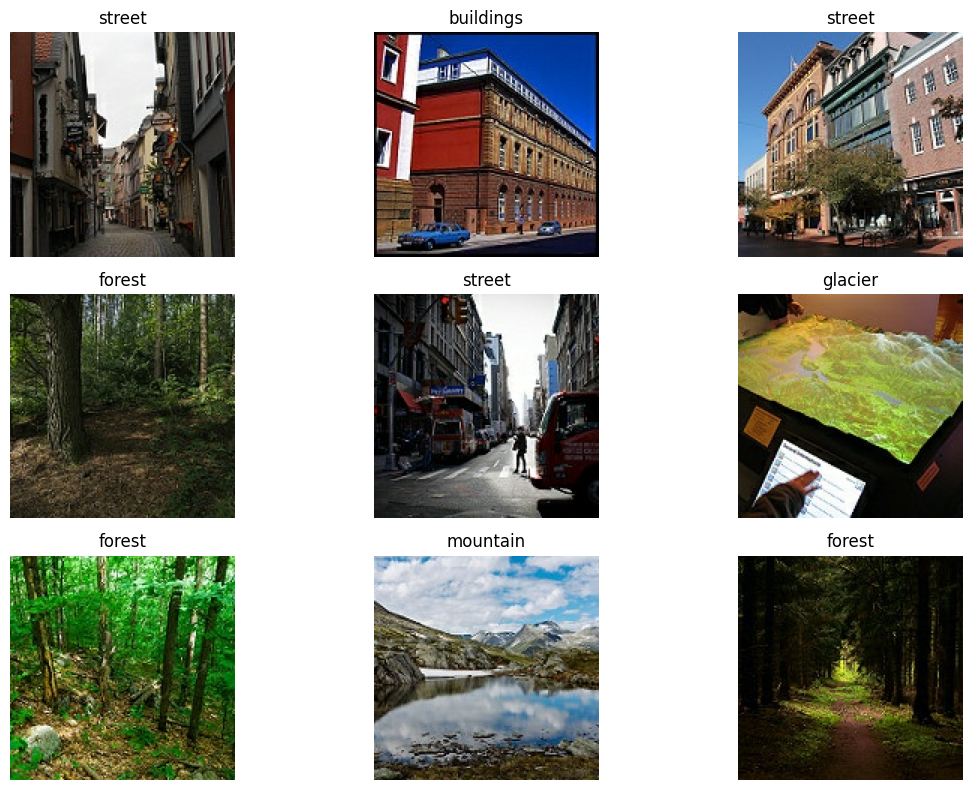

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,896,838 (11.05 MB)

 Trainable params: 2,896,838 (11.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.4416 - loss: 1.3684
Epoch 1: val_accuracy improved from None to 0.60842, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 262s 625ms/step - accuracy: 0.5345 - loss: 1.1684 - val_accuracy: 0.6084 - val_loss: 1.0190 - learning_rate: 0.0010
Epoch 2/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.6264 - loss: 0.9608
Epoch 2: val_accuracy improved from 0.60842 to 0.73680, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 244s 617ms/step - accuracy: 0.6389 - loss: 0.9444 - val_accuracy: 0.7368 - val_loss: 0.7413 - learning_rate: 0.0010
Epoch 3/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.6899 - loss: 0.8365
Epoch 3: val_accuracy improved from 0.73680 to 0.75606, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━

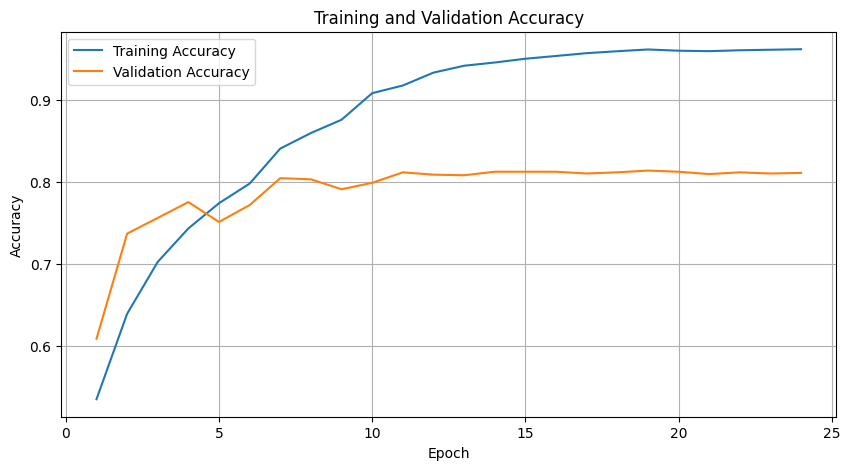

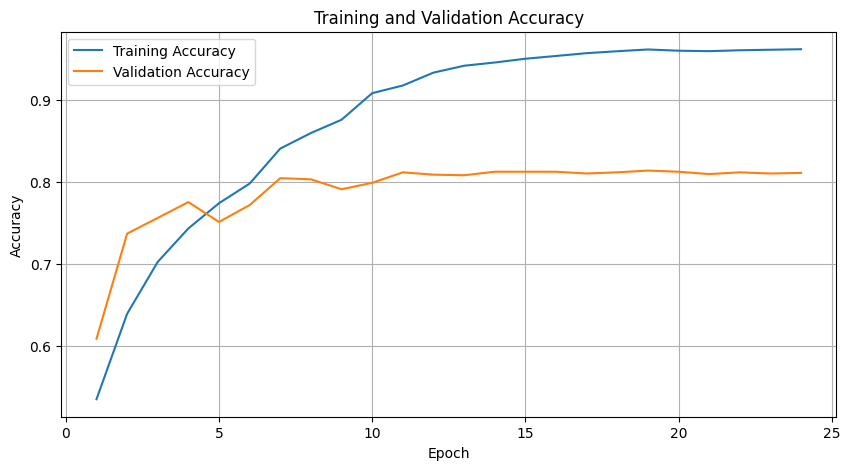

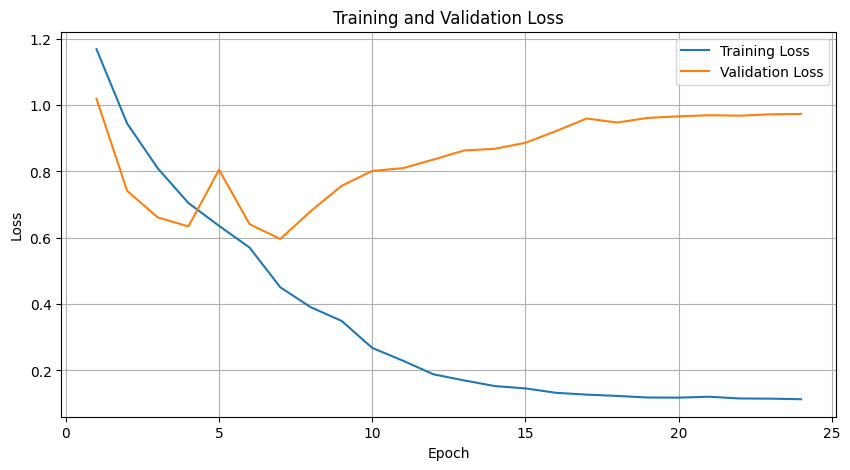

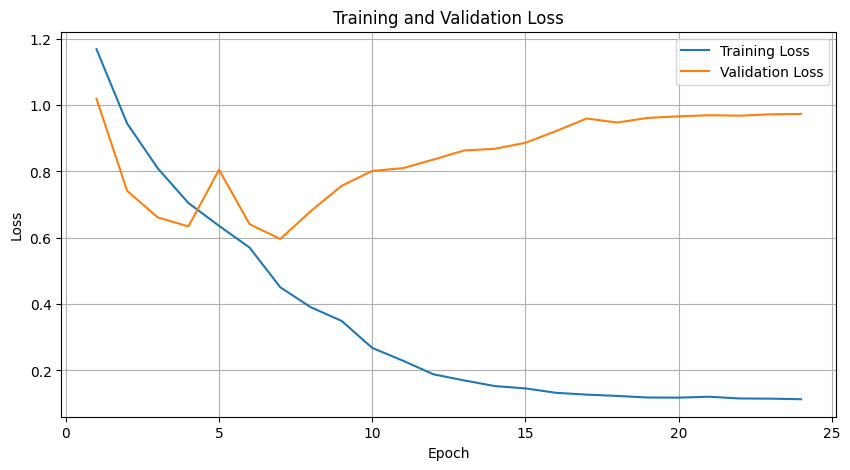

In [4]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

path = kagglehub.dataset_download("blourdhuraju/intel-image-classification-dataset")
print("Path dataset:", path)
print("Isi folder root:", os.listdir(path))

DATASET_DIR = os.path.join(path, "Intel-Image-Classification")
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("Dataset directory:", DATASET_DIR)
print("Train directory:", TRAIN_DIR)
print("Val directory:", VAL_DIR)
print("Test directory:", TEST_DIR)
print("Isi DATASET_DIR:", os.listdir(DATASET_DIR))

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

class StopAtAccuracy(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_acc = logs.get("accuracy", 0)
        val_acc = logs.get("val_accuracy", 0)
        if train_acc >= 0.95 and val_acc >= 0.95:
            print("\nTarget accuracy reached. Stopping training.")
            self.model.stop_training = True

stop_at_acc = StopAtAccuracy()

EPOCHS = 25

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint, stop_at_acc]
)

train_loss, train_acc = model.evaluate(train_ds, verbose=1)
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Val Accuracy   : {val_acc*100:.2f}%")
print(f"Test Accuracy  : {test_acc*100:.2f}%")

acc = history.history["accuracy"]
val_acc_hist = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss_hist = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc_hist, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss_hist, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132573629141584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573629142352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573629143312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573629142544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573629142928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573629144272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573629145232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573629144464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573629145616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573629145424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573629144080: 

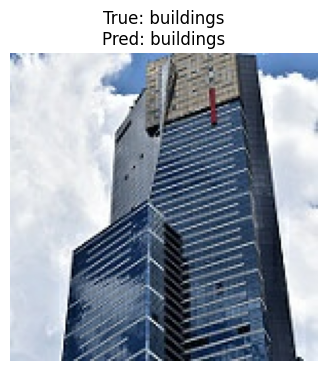

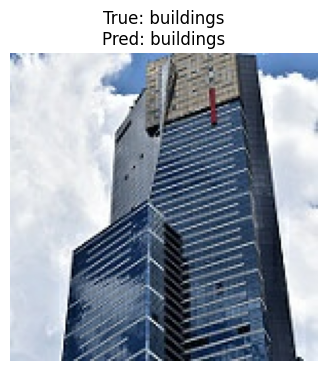

TFLite Prediction : buildings
TFLite Confidence : 1.0
TFLite Prediction : buildings
TFLite Confidence : 1.0


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [5]:
saved_model_path = "saved_model"
model.export(saved_model_path)
print(f"SavedModel saved to: {saved_model_path}")

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved to: model.tflite")

print("Untuk TFJS, jalankan:")
print("pip install tensorflowjs")
print("tensorflowjs_converter --input_format=tf_saved_model saved_model tfjs_model")

for test_images, test_labels in test_ds.take(1):
    sample_img = test_images[0]
    sample_label = test_labels[0].numpy()
    break

img_array = tf.expand_dims(sample_img, axis=0)
pred = model.predict(img_array)
pred_index = np.argmax(pred[0])

print("Ground Truth :", class_names[sample_label])
print("Prediction   :", class_names[pred_index])
print("Confidence   :", float(np.max(pred[0])))

plt.figure(figsize=(4, 4))
plt.imshow(sample_img.numpy().astype("uint8"))
plt.title(f"True: {class_names[sample_label]}\nPred: {class_names[pred_index]}")
plt.axis("off")
plt.show()

interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_data = tf.cast(img_array, dtype=input_details[0]["dtype"]).numpy()
interpreter.set_tensor(input_details[0]["index"], input_data)
interpreter.invoke()

tflite_pred = interpreter.get_tensor(output_details[0]["index"])
tflite_pred_index = np.argmax(tflite_pred[0])

print("TFLite Prediction :", class_names[tflite_pred_index])
print("TFLite Confidence :", float(np.max(tflite_pred[0])))

In [6]:
model.save("model.keras")